# Heston Model Calibration on Real Market Data

Calibrates Heston (1993) to a single day of SPX quotes and evaluates the fit in implied-volatility and total-implied-variance space, with an out-of-sample holdout and static no-arbitrage diagnostics.

---

## Overview
This notebook calibrates the Heston (1993) stochastic volatility model to a single day of SPX option quotes (QUOTE_DATE = 2023-12-29), then checks the calibrated model for static no-arbitrage violations (butterfly and calendar spreads) on the implied total-variance surface.

### Pipeline:

**Data** — load SPX quotes, split into a train set (in-sample calibration) and a test holdout set (out-of-sample evaluation), both restricted to the target quote date.  
**Pricing** — Black-Scholes and Heston semi-analytic pricers  
**Calibration** — least-squares fit of the 5 Heston parameters to market prices (and, separately, to market implied vols).  
**Diagnostics** — RMSE/MAE on price and IV, 3D IV surfaces, 2D smiles, and static no-arbitrage checks (butterfly convexity and calendar monotonicity of total variance).

### The Heston model
Under the risk-neutral measure, the Heston (1993) model specifies the spot price $S_t$ and its instantaneous variance $v_t$ as the solution of the coupled SDEs

$$
\begin{aligned}
dS_t &= rS_t,dt + \sqrt{v_t}S_tdW_t^{S}, \\
dv_t &= \kappa(\theta - v_t)dt + \xi\sqrt{v_t}dW_t^{v}, \\
\end{aligned}
$$

with parameters:  
$v_0$	- initial variance  
$\kappa$	- speed of mean reversion of variance  
$\theta$	- long-run variance level  
$\xi$	- volatility of variance ("vol-of-vol")  
$\rho$	- correlation between the asset and variance Brownian motions  


## Heston semi-analytic pricer
The European call price is recovered from the model's characteristic function via the Heston (1993) / Gatheral-style Fourier inversion:

$$
C_{Heston} = S_0 P_1 - K e^{-rt} P_2, \qquad
P_j = \frac12 + \frac{1}{\pi}\int_0^\infty \operatorname{Re}!\left[\frac{e^{-i\phi\ln K},f_j(\phi)}{i\phi}\right]d\phi,\quad j=1,2
$$

where $f_j$ is the (log-price) characteristic function of the Heston model,

$$
f_j(\phi) = \exp!\big(C(\phi,t) + D(\phi,t),v_0 + i\phi\ln S_0\big)
$$

$$
\begin{aligned}
d &= \sqrt{(\rho\xi i\phi - b_j)^2 - \xi^2(2u_j i\phi - \phi^2)} \\
g &= \frac{b_j - \rho\xi i\phi - d}{b_j - \rho\xi i\phi + d} \\
C(\phi,t) &= ri\phi t + \frac{\kappa\theta}{\xi^2}\Big[(b_j - \rho\xi i\phi - d)t - 2\ln\Big(\frac{1-ge^{-dt}}{1-g}\Big)\Big] \\
D(\phi,t) &= \frac{b_j - \rho\xi i\phi - d}{\xi^2}\cdot\frac{1-e^{-dt}}{1-ge^{-dt}}
\end{aligned}
$$

with $(u_1,b_1)=(\tfrac12,\ \kappa-\rho\xi)$ and $(u_2,b_2)=(-\tfrac12,\ \kappa)$.


Put prices follow from put-call parity, $P = C - S_0 + Ke^{-rt}$.

## 1. Imports and configuration

In [21]:
# ============================================================
# Import packages
# ============================================================

import time
import numpy as np
import pandas as pd

from pathlib import Path
from numpy.polynomial.legendre import leggauss
from scipy.optimize import least_squares
from scipy.integrate import quad
from scipy.stats import norm
from scipy.interpolate import griddata

import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ============================================================
# Configuration
# ============================================================

DATA_PATH = Path("/Users/uran/Desktop/ErdosBootcamp/Project_Quant_Finance/""Quant-Finance-project/Processed_data/surface_all.parquet")

TICKER      = "SPX"
QUOTE_DATE  = "2023-12-29"

HOLDOUT_FRAC = 0.2
MIN_VISIBLE  = 6
SPLIT_SEED   = 0

# --- forward / discount extraction ---
PARITY_MIN_PAIRS = 4
PARITY_BAND      = 0.15

# --- pricer settings ---
GL_NODES    = 384     # Gauss-Legendre nodes; 768 for a final high-accuracy pass, 384 before
# GL_DECAY    = 45.0    # e-folds of the integrand to cover

np.set_printoptions(suppress=True, precision=6)


## 2. Load data, holdout split

In [22]:
# ============================================================
# Load and normalise data
# ============================================================

df = pd.read_parquet(DATA_PATH)

required = {"ticker", "quote_date", "expire_date", "tau", "strike", "type", "mid", "underlying_last",}

df["quote_date"] = pd.to_datetime(df["quote_date"], errors="coerce").dt.strftime("%Y-%m-%d")

df = df.loc[(df["ticker"] == TICKER.upper()) & df["type"].isin(["call", "put"])].copy().reset_index(drop=True)

print(f"{TICKER}: {len(df):,} quotes over {df['quote_date'].nunique()} quote dates")

# ============================================================
# Train / holdout split
# ============================================================

def make_holdout(frame, frac=0.2, min_vis=6, seed=0):
    rng = np.random.default_rng(seed)
    hold = pd.Series(False, index=frame.index)
    for _, sl in frame.groupby(["ticker", "quote_date", "expire_date"]):
        n = len(sl)
        n_hold = min(int(round(frac * n)), max(0, n - min_vis))
        if n_hold > 0:
            hold.loc[rng.choice(sl.index.values, size=n_hold, replace=False)] = True
    return hold


df["is_holdout"] = make_holdout(df, HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED)

day = df[df["quote_date"] == QUOTE_DATE].copy()

train_raw = day[~day["is_holdout"]].copy()
test_raw  = day[ day["is_holdout"]].copy()

print(f"\nQuote date {QUOTE_DATE}")
print(f"  Train: {len(train_raw):,}")
print(f"  Test : {len(test_raw):,}")
print(f"  Number of tau expiries: {day['tau'].nunique()}")
print(f"  Underlying spot median: {day['underlying_last'].median():.2f}")

SPX: 1,462,299 quotes over 249 quote dates

Quote date 2023-12-29
  Train: 5,263
  Test : 1,317
  Number of tau expiries: 42
  Underlying spot median: 4772.17


## 3. Forward and discount factor (DF)

In [23]:
train_f = train_raw.copy()
train_f['F'] = train_f['forward']
train_f['k'] = np.log(train_f['strike'] / train_f['F'])

test_f = test_raw.copy()
test_f['F'] = test_f['forward']
test_f['k'] = np.log(test_f['strike'] / test_f['F'])

## 4. Black-Scholes and the Heston pricer

In [24]:
# ============================================================
# Black-Shcholes (forward measure) and OTM-leg implied volatility
# ============================================================

def black_scholes(F, K, T, sigma, is_call):
    """Black-Shcoles price"""
    sq = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sq**2) / sq
    d2 = d1 - sq
    return np.where(is_call, F * norm.cdf(d1)  - K * norm.cdf(d2), K * norm.cdf(-d2) - F * norm.cdf(-d1))


def black_scholes_vega(F, K, T, sigma):
    sq = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sq**2) / sq
    return F * np.sqrt(T) * norm.pdf(d1)


def black_scholes_iv(F, K, T, undisc_otm_price, lo=1e-4, hi=5.0, iters=100):
    F, K, T, p = (np.asarray(a, float) for a in (F, K, T, undisc_otm_price))
    is_call   = K >= F
    intrinsic = np.maximum(np.where(is_call, F - K, K - F), 0.0)
    cap       = np.where(is_call, F, K)
    ok        = (p > intrinsic + 1e-12) & (p < cap - 1e-12)

    shape = np.broadcast(F, K, T, p).shape
    lo_ = np.full(shape, float(lo))
    hi_ = np.full(shape, float(hi))
    for _ in range(iters):
        mid = 0.5 * (lo_ + hi_)
        too_low = black_scholes(F, K, T, mid, is_call) < p
        lo_ = np.where(too_low, mid, lo_)
        hi_ = np.where(too_low, hi_, mid)

    return np.where(ok, 0.5 * (lo_ + hi_), np.nan)

In [25]:
# ============================================================
# Heston semi-analytic pricer, forward measure
# ============================================================

def heston_call_fwd(F, K, T, v0, kappa, theta, xi, rho, n_nodes=GL_NODES):
    
    F, K, T = (np.atleast_1d(np.asarray(a, float)) for a in (F, K, T))
    F, K, T = np.broadcast_arrays(F, K, T)
    shape = K.shape
    Fr, Kr, Tr = (a.ravel() for a in (F, K, T))
    decay = 45.0 # GL_DECAY

    out = np.empty_like(Kr)
    gx, gw = leggauss(n_nodes)
    i = 1j
    lam_base = np.sqrt(max(1.0 - rho**2, 1e-8)) / xi

    for t in np.unique(Tr):                     # group by maturity: limit adapts
        m   = Tr == t
        lam = lam_base * (v0 + kappa * theta * t)
        U   = decay / max(lam, 1e-12)

        phi = (0.5 * (gx + 1.0) * U)[:, None]
        w   = (0.5 * gw * U)[:, None]
        x   = np.log(Fr[m] / Kr[m])[None, :]

        def P(Pnum):
            u = 0.5 if Pnum == 1 else -0.5
            b = kappa - rho * xi if Pnum == 1 else kappa
            d = np.sqrt((rho * xi * i * phi - b)**2 - xi**2 * (2 * u * i * phi - phi**2))
                        
            g = (b - rho * xi * i * phi - d) / (b - rho * xi * i * phi + d)
            e = np.exp(-d * t)
            C = (kappa * theta / xi**2) * (
                (b - rho * xi * i * phi - d) * t
                - 2 * np.log((1 - g * e) / (1 - g)))
            D = (b - rho * xi * i * phi - d) / xi**2 * ((1 - e) / (1 - g * e))
            f = np.exp(i * phi * x + C + D * v0)
            return 0.5 + np.sum(np.real(f / (i * phi)) * w, axis=0) / np.pi

        out[m] = (Fr[m] * P(1) - Kr[m] * P(2))

    return out.reshape(shape)


def heston_price_fwd(F, K, T, v0, kappa, theta, xi, rho, option_types, **kw):
    """Call or put, via forward parity  C - P = F - K."""
    c = heston_call_fwd(F, K, T, v0, kappa, theta, xi, rho, **kw)
    is_put = np.asarray(option_types) == "put"
    return np.where(is_put, c - (F - K), c)


def heston_iv(F, K, T, v0, kappa, theta, xi, rho, **kw):
    """Heston -> Black-Scholes implied vol"""
    c   = heston_call_fwd(F, K, T, v0, kappa, theta, xi, rho, **kw)
    otm = np.where(K >= F, c, c - (F - K))
    return black_scholes_iv(F, K, T, otm)


def heston_total_variance(F, K, T, v0, kappa, theta, xi, rho, **kw):
    """w(k, tau) = sigma_BS(k, tau)^2 * tau under Heston."""
    return heston_iv(F, K, T, v0, kappa, theta, xi, rho, **kw)**2 * np.asarray(T, float)

## 5. Quote filters

In [26]:
# ============================================================
# Filter quotes and recompute market IV on a consistent convention
# ============================================================

def prepare_quotes(frame):
    out = frame.copy()
    out["otm_undisc"] = out["mid"]
    # out["market_iv"]  = black_scholes_iv(out["F"].to_numpy(float), out["strike"].to_numpy(float), out["tau"].to_numpy(float), out["otm_undisc"].to_numpy(float))
    out['market_iv'] = out['iv'] 

    out["market_w"] = out["market_iv"]**2 * out["tau"]
    out["vega"]     = black_scholes_vega(out["F"], out["strike"], out["tau"],out["market_iv"])

    print(f"  {len(out):6,}")
    return out.reset_index(drop=True)


print("TRAIN")
train = prepare_quotes(train_f)
print("\nTEST")
test  = prepare_quotes(test_f)

TRAIN
   5,263

TEST
   1,317


## 7. Calibration

Three objectives, all on the same filtered quote set. Each residual vector has a
**fixed length and a fixed mask**, decided once from the market data. Nothing is
penalised in-loop.

$$
\begin{aligned}
\texttt{iv}    &: \quad r_i = \sigma^{\text{model}}_i - \sigma^{\text{mkt}}_i \\
% \texttt{vega}  &: \quad r_i = \bigl(\sigma^{\text{model}}_i - \sigma^{\text{mkt}}_i\bigr)\cdot \frac{\nu_i}{\bar\nu} \\
\texttt{norm\_w} &: \quad r_i = \frac{w^{\text{model}}_i - w^{\text{mkt}}_i}{w^{\text{mkt}}_i}
\end{aligned}
$$

`norm_w` is the total-variance objective, rescaled.

In [ ]:
# ============================================================
# Objectives and calibration driver
# ============================================================

BOUNDS = (np.array([1e-4, 1e-2, 1e-4, 1e-2, -0.995]),   # v0, kappa, theta, xi, rho
          np.array([1.0,  25.0, 1.0,  5.0,   0.50 ]))

STARTS = [
    # np.array([0.015,  2.0, 0.04, 1.0, -0.75]),
    # np.array([0.010,  5.0, 0.05, 2.0, -0.85]),
    # np.array([0.030,  1.0, 0.03, 1.5, -0.60]),
    np.array([0.040,  1.5, 0.04, 0.6, -0.70]),   
]


def make_residual(frame, objective="iv", n_nodes=GL_NODES):
    """
    Build a residual function
    """
    F  = frame["F"].to_numpy(float)
    K  = frame["strike"].to_numpy(float)
    T  = frame["tau"].to_numpy(float)
    iv_mkt = frame["market_iv"].to_numpy(float)
    w_mkt  = frame["market_w"].to_numpy(float)

    if objective == "vega":
        wgt = frame["vega"].to_numpy(float)
        wgt = wgt / wgt.mean()
    else:
        wgt = np.ones_like(iv_mkt)

    def resid(p):
        v0, kappa, theta, xi, rho = p
        iv = heston_iv(F, K, T, v0, kappa, theta, xi, rho, n_nodes=n_nodes)
        bad = ~np.isfinite(iv)
        iv_safe = np.where(bad, iv_mkt, iv)
        if objective == "norm_w":
            r = (iv_safe**2 * T - w_mkt) / w_mkt
        else:
            r = iv_safe - iv_mkt
        return r * wgt

    return resid


def calibrate(frame, objective="iv", starts=STARTS, bounds=BOUNDS, n_nodes=GL_NODES, verbose=False):
    resid = make_residual(frame, objective, n_nodes)
    best = None
    for x0 in starts:
        x0c = np.clip(x0, bounds[0] + 1e-9, bounds[1] - 1e-9)
        out = least_squares(resid, x0=x0c, bounds=bounds, x_scale="jac", diff_step=1e-6, max_nfev=1000, verbose=2 if verbose else 0)
        if best is None or out.cost < best.cost:
            best = out
    return best

In [28]:
# ============================================================
# Run the calibration
# ============================================================

PARAM_NAMES = ["v0", "kappa", "theta", "xi", "rho"]
results = {}

for obj in ["norm_w"]: # iv, vega, norm_w
    print(obj)
    t0 = time.perf_counter()
    results[obj] = calibrate(train, objective=obj)
    dt = time.perf_counter() - t0
    p = results[obj].x
    print(f"Total implied variance, {obj:7s}  " + "  ".join(f"{n}={v:8.5f}" for n, v in zip(PARAM_NAMES, p)) + f"   cost {results[obj].cost:.6e}   [{dt:5.1f}s] ")

PARAMS = results["norm_w"].x

norm_w
Total implied variance, norm_w   v0= 0.00691  kappa= 8.42964  theta= 0.03366  xi= 1.49455  rho=-0.60830   cost 9.070543e+01   [509.8s] 


## 8. Diagnostics

In [36]:
# ============================================================
# Attach model values and compute errors
# ============================================================

def score(frame, params, n_nodes=768, label=""):
    """Attach model IV / w / price and the corresponding errors."""
    out = frame.copy()
    v0, kappa, theta, xi, rho = params
    F = out["F"].to_numpy(float)
    K = out["strike"].to_numpy(float)
    T = out["tau"].to_numpy(float)

    out["heston_iv"]    = heston_iv(F, K, T, v0, kappa, theta, xi, rho, n_nodes=n_nodes)
    out["heston_w"]     = out["heston_iv"]**2 * out["tau"]
    out["heston_price"] = heston_price_fwd(F, K, T, v0, kappa, theta, xi, rho, out["type"].to_numpy(), n_nodes=n_nodes)

    out["iv_error"]    = out["heston_iv"]    - out["market_iv"]
    out["w_error"]     = out["heston_w"]     - out["market_w"]      
    out["w_rel_error"] = out["w_error"] / out["market_w"]
    out["price_error"] = out["heston_price"] - out["mid"]
    return out


def report(frame, label):
    e_iv, e_w, e_p = frame["iv_error"], frame["w_rel_error"], frame["price_error"]
    print(f"{label}")
    print("-" * 46)
    print(f"  IV   RMSE  {np.sqrt(np.mean(e_iv**2)):8.4f} " f" MAE {np.mean(np.abs(e_iv)):8.4f}")
    print(f"  w    RMSE  {np.sqrt(np.mean(frame['w_error']**2)):8.6f}" f"\t\t MAE {np.mean(np.abs(frame['w_error'])):8.6f}")
    # print(f"  w/w  RMSE  {np.sqrt(np.mean(e_w**2))*100:8.4f} %" f"\t\t MAE {np.mean(np.abs(e_w))*100:8.4f} %")
    # print(f"  price RMSE {np.sqrt(np.mean(e_p**2)):8.4f}" f"\t\t MAE {np.mean(np.abs(e_p)):8.4f}")


train_s = score(train, PARAMS)
report(train_s, f"TRAIN  ({len(train_s):,} quotes)")

TRAIN  (5,263 quotes)
----------------------------------------------
  IV   RMSE    0.0305  MAE   0.0161
  w    RMSE  0.003342		 MAE 0.001419


## 9. Smiles and surface

Plotted against log-forward-moneyness $k = \ln(K/F)$ and sorted.

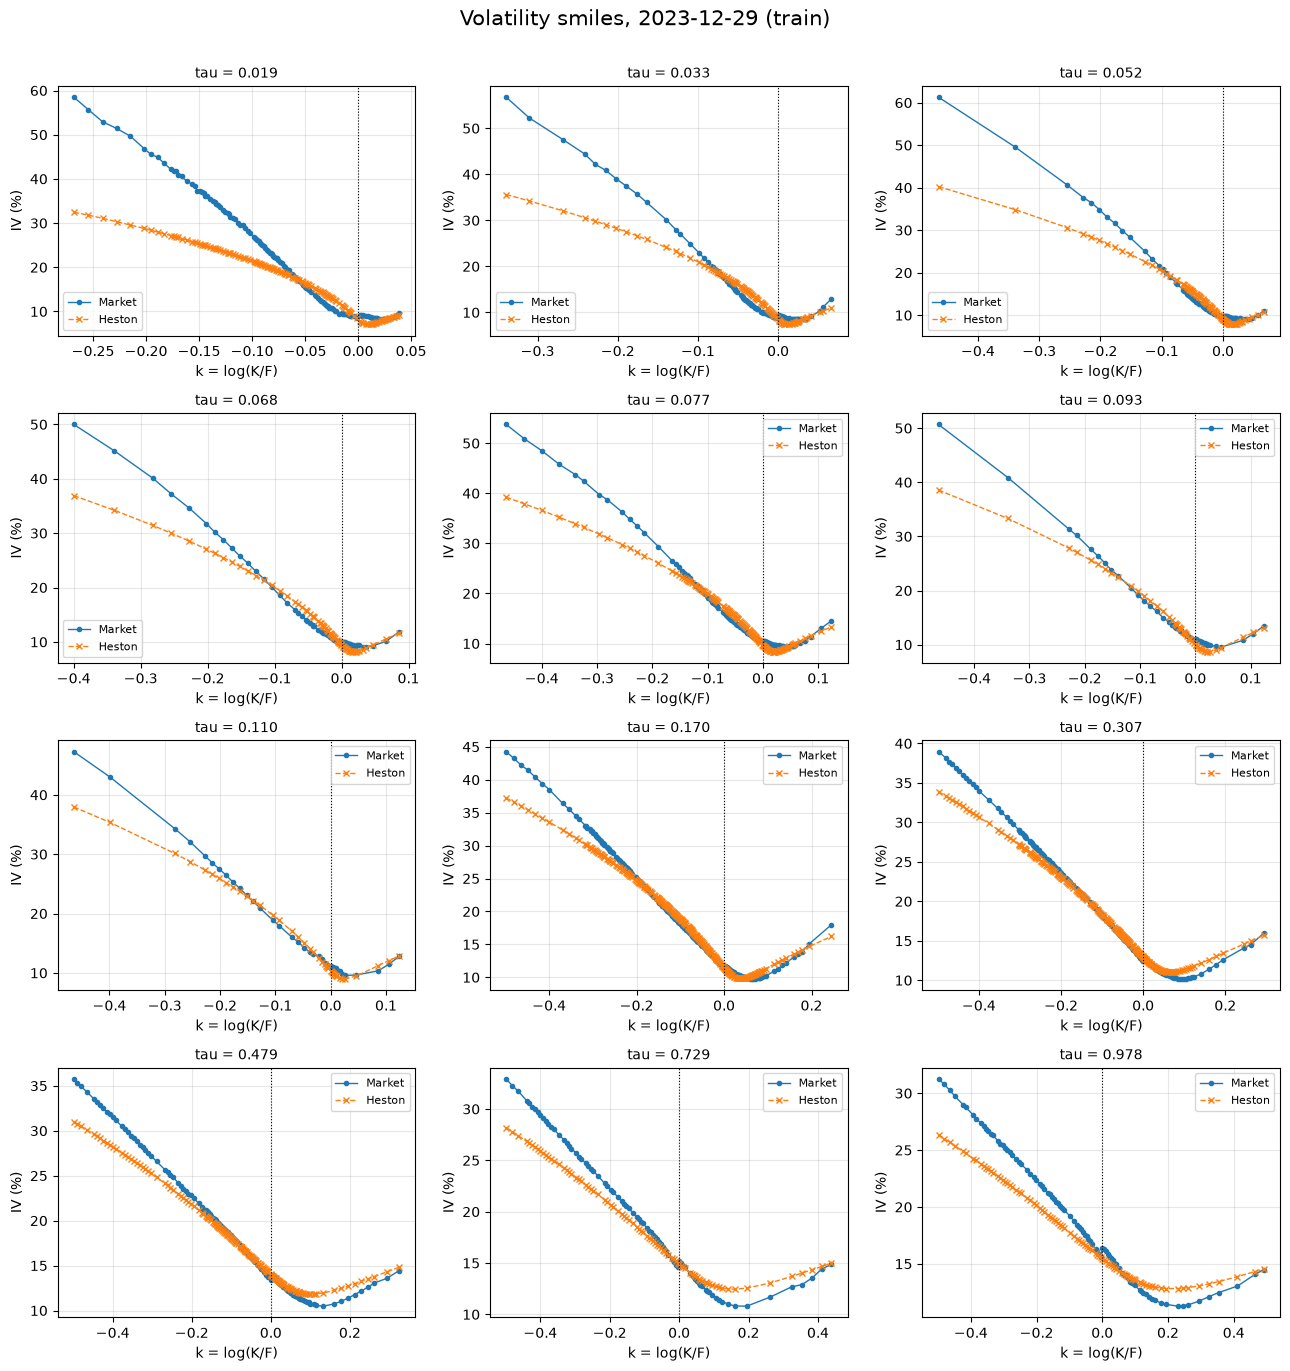

In [37]:
# ============================================================
# 2D smiles by maturity
# ============================================================

def plot_smiles(frame, title, n_max=12, n_cols=3):
    taus = np.sort(frame["tau"].unique())
    sel = taus[np.linspace(0, len(taus) - 1, min(n_max, len(taus))).astype(int)]
    n_rows = int(np.ceil(len(sel) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, t in zip(axes, sel):
        sub = frame[frame["tau"] == t].sort_values("k")
        ax.plot(sub["k"], sub["market_iv"] * 100, "o-", ms=3, lw=1, label="Market") 
        # ax.plot(sub["k"], sub["iv"] * 100, "o-", ms=3, lw=1, label="Market") # NEW
        ax.plot(sub["k"], sub["heston_iv"] * 100, "x--", ms=4, lw=1, label="Heston")
        ax.axvline(0, ls=":", c="k", lw=0.8)
        # rmse = np.sqrt(np.mean(sub["iv_error"]**2)) * 100
        # ax.set_title(f"tau = {t:.3f}   RMSE {rmse:.2f} pts", fontsize=10)
        ax.set_title(f"tau = {t:.3f}", fontsize=10)
        ax.set_xlabel("k = log(K/F)"); ax.set_ylabel("IV (%)")
        ax.grid(alpha=0.3); ax.legend(fontsize=8)

    for j in range(len(sel), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=15, y=1.005)
    plt.tight_layout(); plt.show()


plot_smiles(train_s, f"Volatility smiles, {QUOTE_DATE} (train)")

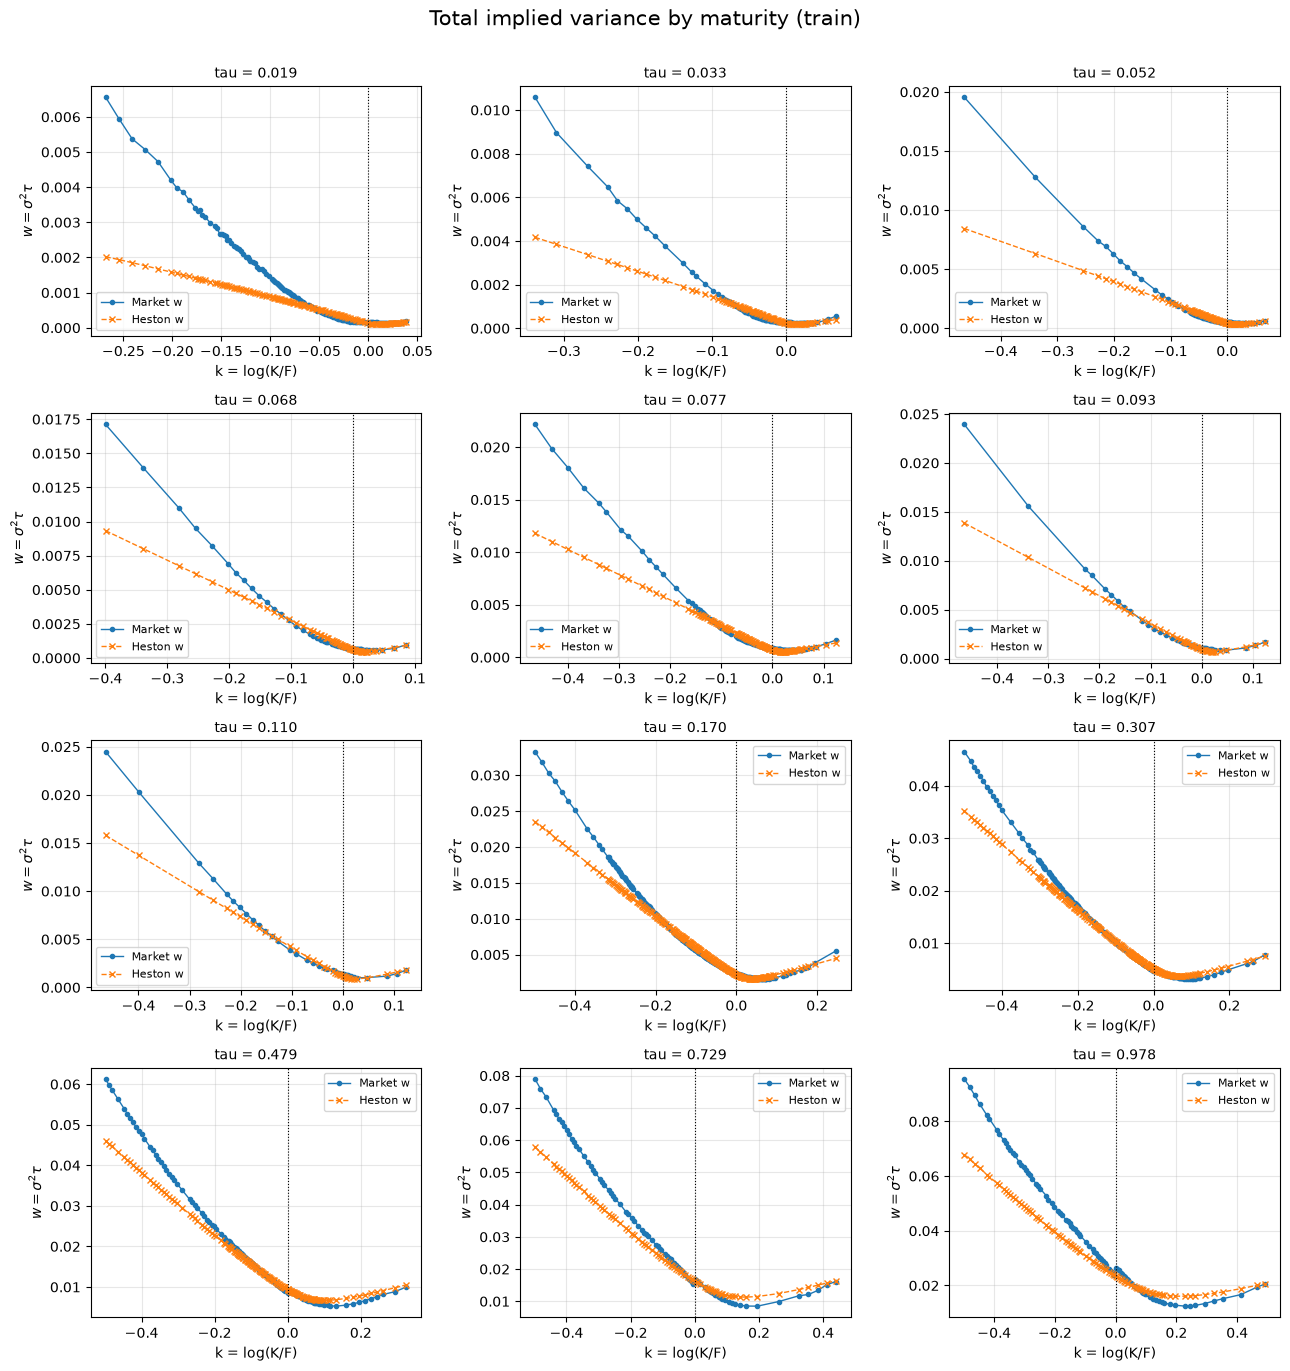

In [38]:
# ============================================================
# Total variance smiles -- the quantity actually being calibrated
# ============================================================

def plot_total_variance(frame, title, n_max=12, n_cols=3):
    taus = np.sort(frame["tau"].unique())
    sel = taus[np.linspace(0, len(taus) - 1, min(n_max, len(taus))).astype(int)]
    n_rows = int(np.ceil(len(sel) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 3.4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, t in zip(axes, sel):
        sub = frame[frame["tau"] == t].sort_values("k")
        ax.plot(sub["k"], sub["market_w"], "o-", ms=3, lw=1, label="Market w")
        ax.plot(sub["k"], sub["heston_w"], "x--", ms=4, lw=1, label="Heston w")
        ax.axvline(0, ls=":", c="k", lw=0.8)
        ax.set_title(f"tau = {t:.3f}", fontsize=10)
        ax.set_xlabel("k = log(K/F)"); ax.set_ylabel(r"$w = \sigma^2\tau$")
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    for j in range(len(sel), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=15, y=1.005)
    plt.tight_layout(); plt.show()


plot_total_variance(train_s, "Total implied variance by maturity (train)")

## 10. Out-of-sample holdout

Same parameters, quotes withheld from calibration. The holdout is drawn from
within each expiry, so this measures interpolation across strike, not
extrapolation to new maturities.

TRAIN  (5,263 quotes)
----------------------------------------------
  IV   RMSE    0.0305  MAE   0.0161
  w    RMSE  0.003342		 MAE 0.001419

TEST   (1,317 quotes)
----------------------------------------------
  IV   RMSE    0.0288  MAE   0.0160
  w    RMSE  0.003421		 MAE 0.001461

Train and test errors should be close: with 5 parameters against 5,263


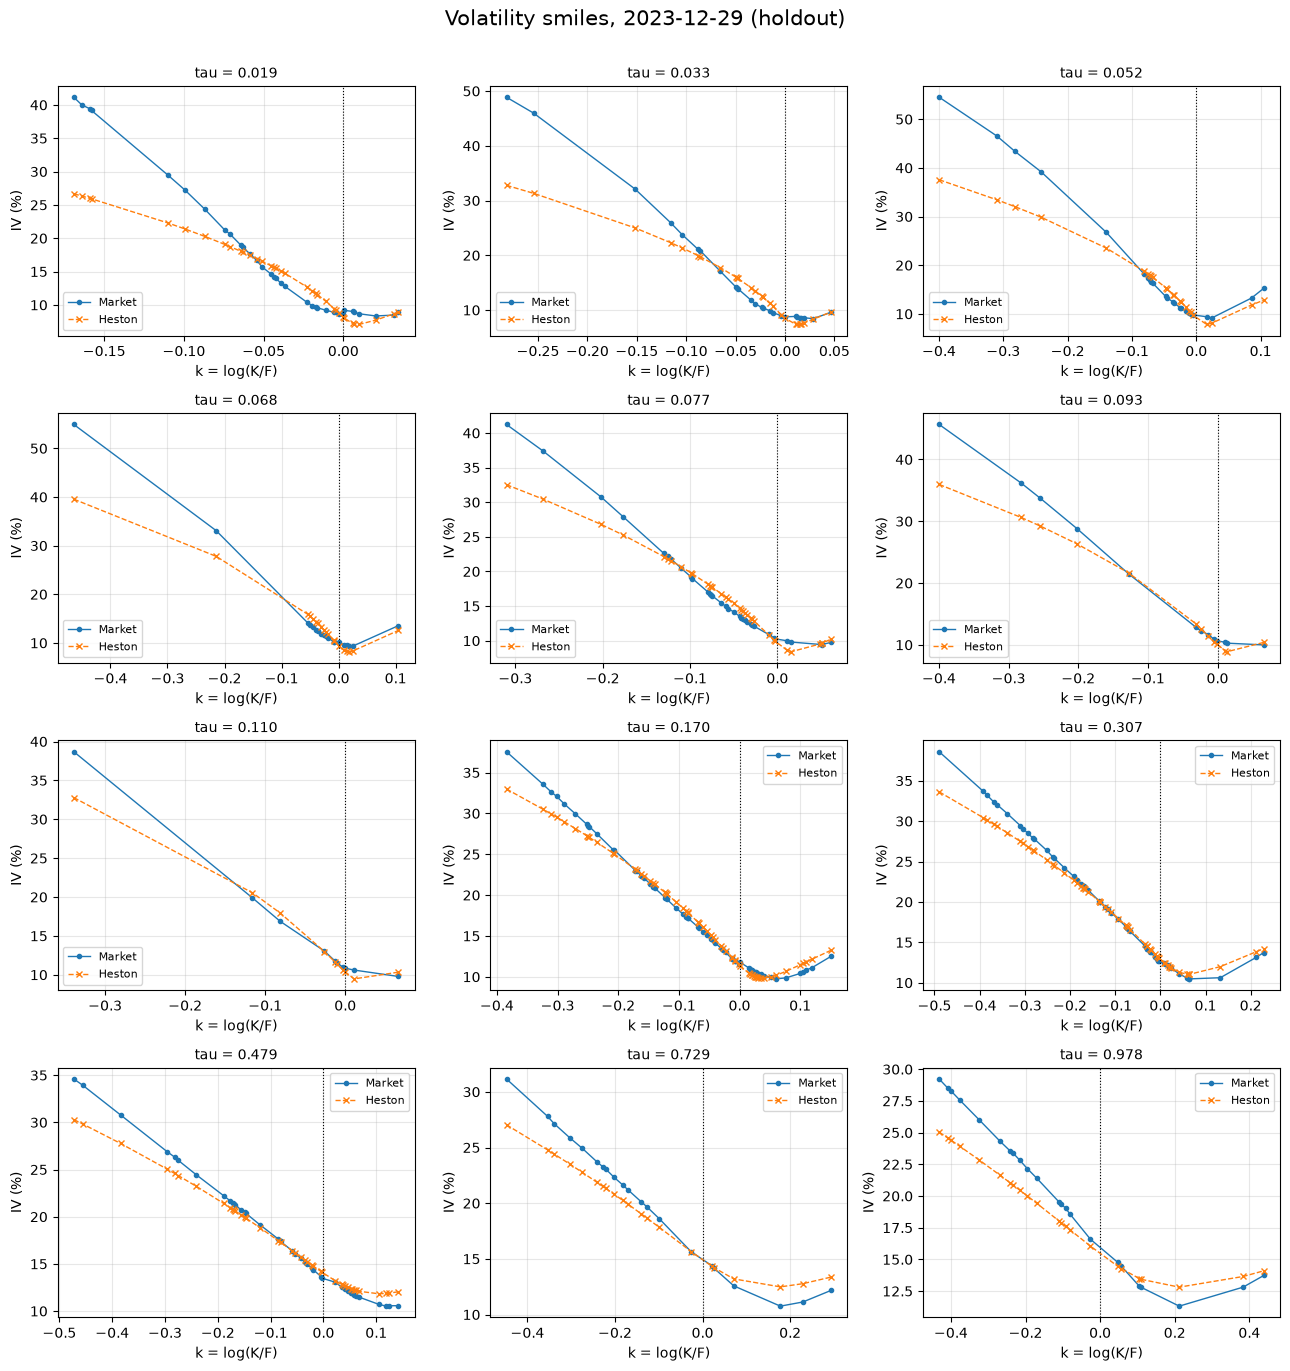

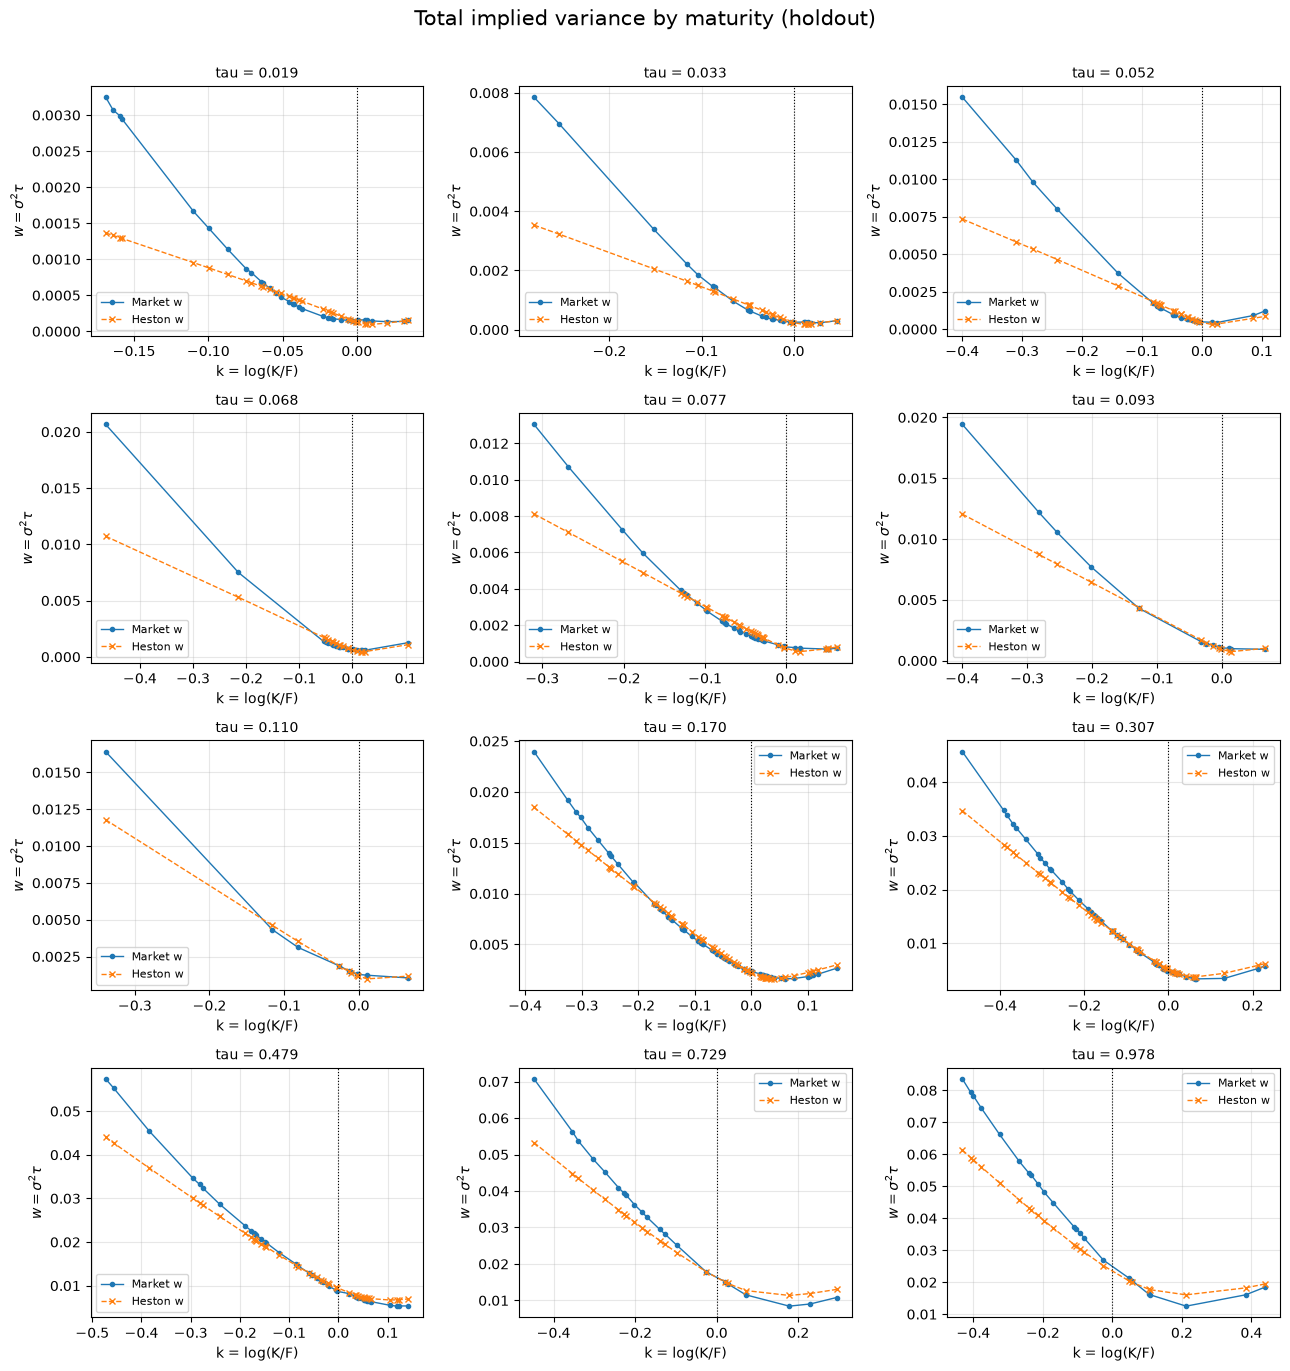

In [39]:
# ============================================================
# Apply calibrated parameters to the holdout set
# ============================================================

test_s = score(test, PARAMS)

report(train_s, f"TRAIN  ({len(train_s):,} quotes)")
print()
report(test_s,  f"TEST   ({len(test_s):,} quotes)")

print("\nTrain and test errors should be close: with 5 parameters against" f" {len(train_s):,}")

plot_smiles(test_s, f"Volatility smiles, {QUOTE_DATE} (holdout)")

plot_total_variance(test_s, "Total implied variance by maturity (holdout)")

## 11. Static no-arbitrage checks

### Butterfly

A smile is free of butterfly arbitrage iff the risk-neutral density is
non-negative, which on the total implied variance $w(k,\tau) = \tau\,\sigma_{BS}(k,\tau)^2$
is equivalent (Gatheral & Jacquier, 2014) to

$$
g(k) = \left(1 - \frac{k\,w'(k)}{2w(k)}\right)^{2}
     - \frac{w'(k)^{2}}{4}\left(\frac{1}{w(k)} + \frac14\right)
     + \frac{w''(k)}{2} \;\ge\; 0 \quad \forall k .
$$

Any $k$ with $g(k) < 0$ is a strike where the implied density goes negative.

### Calendar

Independently of each slice's shape, the surface is free of calendar arbitrage
iff total variance is non-decreasing in maturity at fixed $k$:

$$\frac{\partial w(k,\tau)}{\partial \tau} \;\ge\; 0 .$$

In [ ]:
# ============================================================
# Butterfly and calendar checks on the calibrated surface
# ============================================================

v0, kappa, theta, xi, rho = PARAMS
taus_grid = np.linspace(train["tau"].min(), train["tau"].max(), 40)
k_line    = np.linspace(-0.35, 0.20, 121)
eps       = 1e-3

def w_of(k, t):
    F = 1.0                                   # w is invariant to the F scale
    return heston_total_variance(F, np.exp(np.asarray(k, float)), np.full(np.shape(k), t), v0, kappa, theta, xi, rho, n_nodes=768)

# ---- butterfly ----
g_grid = np.full((len(taus_grid), len(k_line)), np.nan)
for j, t in enumerate(taus_grid):
    w  = w_of(k_line, t)
    wp = (w_of(k_line + eps, t) - w_of(k_line - eps, t)) / (2 * eps)
    wpp = (w_of(k_line + eps, t) - 2 * w + w_of(k_line - eps, t)) / eps**2
    g_grid[j] = ((1 - k_line * wp / (2 * w))**2 - (wp**2 / 4) * (1 / w + 0.25) + wpp / 2)

# far wings at short tau are worth less than a float can represent, so they
# have no invertible IV; count them separately rather than silently as "fine"
n_nan = int(np.sum(~np.isfinite(g_grid)))
n_bf  = int(np.sum(g_grid < 0))
print(f"Butterfly: {n_bf} "
      f"with g(k) < 0   (min g = {np.nanmin(g_grid):+.6f})")

# ---- calendar ----
w_kt = np.array([w_of(k_line, t) for t in taus_grid])
dw = np.diff(w_kt, axis=0)
finite = np.isfinite(dw)
n_cal = int(np.sum(dw[finite] < 0))
print(f"Calendar:  {n_cal} "
      f"with dw/dtau < 0   (min dw = {dw[finite].min():+.3e})")
print("\nBoth should be zero. Heston is arbitrage-free analytically, so any violation is a numerical artefact of the pricer or the IV inversion.")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
# lim = max(abs(np.nanmin(g_grid)), 1e-6)
# c0 = ax[0].contourf(k_line, taus_grid, np.nan_to_num(g_grid, nan=0.0),
#                     levels=24, cmap="RdBu_r", vmin=-lim, vmax=lim)
# ax[0].set_title("Butterfly diagnostic g(k)"); ax[0].set_xlabel("k"); ax[0].set_ylabel("tau")
# plt.colorbar(c0, ax=ax[0])

for kk in np.linspace(-0.3, 0.15, 7):
    w_line = np.array([w_of([kk], t)[0] for t in taus_grid])
    ax.plot(taus_grid, w_line, label=f"k = {kk:+.2f}")
ax.set_xlabel("tau (time to maturity)"); ax.set_ylabel(r"$w(k,\tau)$")
ax.set_title("Calendar check. Total variance vs maturity (must be non-decreasing)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Butterfly: 0 with g(k) < 0   (min g = +0.265952)


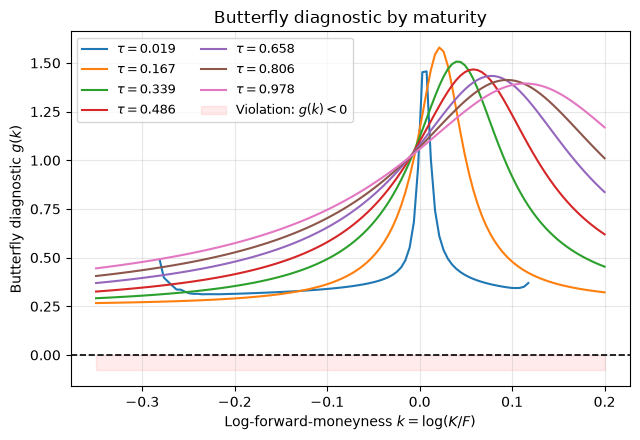

In [ ]:
# Plot g(k) for representative maturities
fig, ax = plt.subplots(figsize=(6.5, 4.5))

selected = np.unique(np.linspace(0, len(taus_grid) - 1, 7).astype(int))

for j in selected:
    finite = np.isfinite(g_grid[j])
    ax.plot(k_line[finite], g_grid[j, finite], lw=1.5, label=fr"$\tau={taus_grid[j]:.3f}$")

# Butterfly-arbitrage boundary
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2)
ax.fill_between(k_line, ax.get_ylim()[0], 0, color="red", alpha=0.08, label=r"Violation: $g(k)<0$")

ax.set_xlabel(r"Log-forward-moneyness $k=\log(K/F)$")
ax.set_ylabel(r"Butterfly diagnostic $g(k)$")
ax.set_title("Butterfly diagnostic by maturity")
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

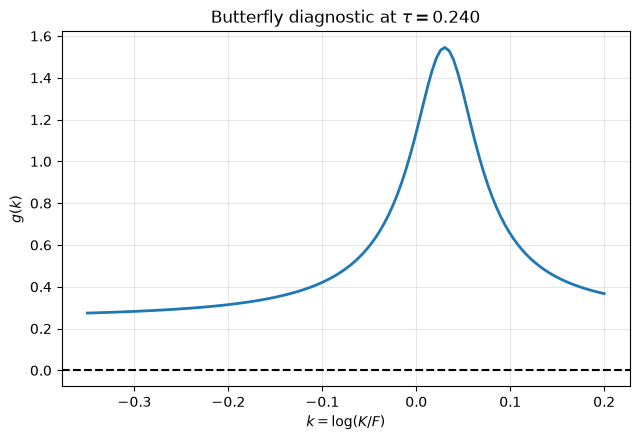

In [ ]:
target_tau = 0.25
j = np.argmin(np.abs(taus_grid - target_tau))

plt.figure(figsize=(6.5, 4.5))
plt.plot(k_line, g_grid[j], lw=2)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel(r"$k=\log(K/F)$")
plt.ylabel(r"$g(k)$")
plt.title(fr"Butterfly diagnostic at $\tau={taus_grid[j]:.3f}$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()